<a href="https://colab.research.google.com/github/sway4em/566-cricket-colab/blob/main/566_cricket_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building the Best IPL Team
## Player Archetype Discovery via Unsupervised Learning

**Train:** 2008 - 2024 | **Test:** 2025 - 2026

### Setup
Upload your `data/` folder to Google Drive. Update `DATA_DIR` below to point to it.

In [1]:
# Mount Google Drive and install dependencies
from google.colab import drive
drive.mount('/content/drive')

!pip install -q umap-learn

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import os
import glob
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy import stats

import umap
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

# UPDATE THIS PATH to where you uploaded the data/ folder in Google Drive
DATA_DIR = Path('/content/drive/MyDrive/566-term-project/data')

# Output directory for saved figures
OUTPUT_DIR = Path('/content/drive/MyDrive/566-term-project/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Phase 1: Load and Combine Data

In [3]:
csv_files = list(DATA_DIR.glob('*.csv'))
print(f"Found {len(csv_files)} match files")

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    dfs.append(df)

ball_data = pd.concat(dfs, ignore_index=True)
print(f"Total deliveries: {len(ball_data):,}")
print(f"Seasons (raw): {ball_data['season'].unique()}")
ball_data.head()

Found 1243 match files
Total deliveries: 295,732
Seasons (raw): [2013 2024 2023 2012 2016 2011 2019 '2020/21' 2017 2015 2018 2009 2026
 2014 '2009/10' 2025 '2007/08' 2022 2021]


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,598002,2013,2013-04-06,"MA Chidambaram Stadium, Chepauk",1,0.1,Mumbai Indians,Chennai Super Kings,RT Ponting,SR Tendulkar,DP Nannes,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,598002,2013,2013-04-06,"MA Chidambaram Stadium, Chepauk",1,0.2,Mumbai Indians,Chennai Super Kings,RT Ponting,SR Tendulkar,DP Nannes,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,598002,2013,2013-04-06,"MA Chidambaram Stadium, Chepauk",1,0.3,Mumbai Indians,Chennai Super Kings,RT Ponting,SR Tendulkar,DP Nannes,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,598002,2013,2013-04-06,"MA Chidambaram Stadium, Chepauk",1,0.4,Mumbai Indians,Chennai Super Kings,RT Ponting,SR Tendulkar,DP Nannes,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,598002,2013,2013-04-06,"MA Chidambaram Stadium, Chepauk",1,0.5,Mumbai Indians,Chennai Super Kings,SR Tendulkar,RT Ponting,DP Nannes,0,0,NaN,NaN,NaN,NaN,NaN,lbw,SR Tendulkar,NaN,NaN


In [4]:
# Normalize season labels
season_map = {
    '2007/08': '2008',
    '2009/10': '2010',
    '2020/21': '2020',
}
ball_data['season'] = ball_data['season'].astype(str).replace(season_map)
ball_data['season'] = ball_data['season'].astype(int)
print(f"Seasons after normalization: {sorted(ball_data['season'].unique())}")

Seasons after normalization: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [5]:
# Train/test split by season
TEST_SEASONS = [2025, 2026]
train_data = ball_data[~ball_data['season'].isin(TEST_SEASONS)].copy()
test_data = ball_data[ball_data['season'].isin(TEST_SEASONS)].copy()

print(f"Train: {len(train_data):,} deliveries ({train_data['season'].min()}-{train_data['season'].max()})")
print(f"Test:  {len(test_data):,} deliveries (seasons {TEST_SEASONS})")

Train: 260,920 deliveries (2008-2024)
Test:  34,812 deliveries (seasons [2025, 2026])


## Phase 2: Feature Engineering

Compute per-player, per-season feature vectors. We define three game phases:
- **Powerplay:** Overs 1-6
- **Middle:** Overs 7-15
- **Death:** Overs 16-20

In [6]:
def get_phase(ball_col):
    """Map ball number (e.g. 3.4 means over 4, ball 4) to game phase."""
    over = ball_col.astype(str).str.split('.').str[0].astype(int)
    phase = pd.Series('middle', index=ball_col.index)
    phase[over < 6] = 'powerplay'
    phase[over >= 15] = 'death'
    return phase

train_data['phase'] = get_phase(train_data['ball'])
test_data['phase'] = get_phase(test_data['ball'])

train_data['phase'].value_counts()

,count
phase,
middle,119552
powerplay,81905
death,59463


In [7]:
def compute_batting_features(data):
    """Compute per-player, per-season batting features."""
    # Each row where the player is the striker counts as a ball faced
    # (unless it's a wide, which doesn't count as a ball faced)
    batting = data[data['wides'].isna() | (data['wides'] == 0)].copy()
    batting['is_boundary'] = batting['runs_off_bat'].isin([4, 6]).astype(int)
    batting['is_six'] = (batting['runs_off_bat'] == 6).astype(int)
    batting['is_dot'] = (batting['runs_off_bat'] == 0).astype(int)
    batting['is_dismissed'] = batting['player_dismissed'].notna().astype(int)

    group_cols = ['striker', 'season']

    # Overall stats
    overall = batting.groupby(group_cols).agg(
        total_runs=('runs_off_bat', 'sum'),
        balls_faced=('runs_off_bat', 'count'),
        boundaries=('is_boundary', 'sum'),
        sixes=('is_six', 'sum'),
        dots=('is_dot', 'sum'),
        dismissals=('is_dismissed', 'sum'),
    ).reset_index()

    overall['strike_rate'] = (overall['total_runs'] / overall['balls_faced']) * 100
    overall['boundary_pct'] = overall['boundaries'] / overall['balls_faced']
    overall['six_pct'] = overall['sixes'] / overall['balls_faced']
    overall['dot_pct'] = overall['dots'] / overall['balls_faced']
    overall['average'] = overall['total_runs'] / overall['dismissals'].clip(lower=1)

    # Phase-wise strike rates
    phase_sr = batting.groupby(group_cols + ['phase']).agg(
        phase_runs=('runs_off_bat', 'sum'),
        phase_balls=('runs_off_bat', 'count'),
        phase_dots=('is_dot', 'sum'),
        phase_boundaries=('is_boundary', 'sum'),
    ).reset_index()

    phase_sr['phase_sr'] = (phase_sr['phase_runs'] / phase_sr['phase_balls']) * 100
    phase_sr['phase_dot_pct'] = phase_sr['phase_dots'] / phase_sr['phase_balls']
    phase_sr['phase_boundary_pct'] = phase_sr['phase_boundaries'] / phase_sr['phase_balls']

    # Pivot phases into columns
    for metric in ['phase_sr', 'phase_dot_pct', 'phase_boundary_pct']:
        pivot = phase_sr.pivot_table(
            index=group_cols, columns='phase', values=metric
        ).reset_index()
        pivot.columns = [f'bat_{metric}_{c}' if c in ['powerplay', 'middle', 'death'] else c
                        for c in pivot.columns]
        overall = overall.merge(pivot, on=group_cols, how='left')

    # Consistency: std of runs per innings
    innings_runs = batting.groupby(['striker', 'season', 'match_id', 'innings']).agg(
        innings_runs=('runs_off_bat', 'sum'),
        innings_balls=('runs_off_bat', 'count'),
    ).reset_index()

    consistency = innings_runs.groupby(group_cols).agg(
        runs_std=('innings_runs', 'std'),
        avg_balls_per_innings=('innings_balls', 'mean'),
        num_innings=('innings_runs', 'count'),
    ).reset_index()

    overall = overall.merge(consistency, on=group_cols, how='left')

    # Acceleration: death SR / powerplay SR
    pp_col = 'bat_phase_sr_powerplay'
    death_col = 'bat_phase_sr_death'
    if pp_col in overall.columns and death_col in overall.columns:
        overall['acceleration'] = overall[death_col] / overall[pp_col].clip(lower=1)

    overall = overall.rename(columns={'striker': 'player'})
    return overall

bat_train = compute_batting_features(train_data)
bat_test = compute_batting_features(test_data)
print(f"Batting features: {bat_train.shape}")
bat_train.head()

Batting features: (2617, 26)


,player,season,total_runs,balls_faced,boundaries,sixes,dots,dismissals,strike_rate,boundary_pct,six_pct,dot_pct,average,bat_phase_sr_death,bat_phase_sr_middle,bat_phase_sr_powerplay,bat_phase_dot_pct_death,bat_phase_dot_pct_middle,bat_phase_dot_pct_powerplay,bat_phase_boundary_pct_death,bat_phase_boundary_pct_middle,bat_phase_boundary_pct_powerplay,runs_std,avg_balls_per_innings,num_innings,acceleration
0,A Ashish Reddy,2012,35,29,4,1,12,4,120.689655,0.137931,0.034483,0.413793,8.750000,119.047619,125.000000,NaN,0.380952,0.500000,NaN,0.142857,0.125000,NaN,3.316625,5.800000,5,NaN
1,A Ashish Reddy,2013,125,89,13,5,24,6,140.449438,0.146067,0.056180,0.269663,20.833333,146.153846,120.000000,83.333333,0.243590,0.200000,0.666667,0.153846,0.000000,0.166667,9.947082,8.900000,10,1.753846
2,A Ashish Reddy,2015,73,46,8,5,13,3,158.695652,0.173913,0.108696,0.282609,24.333333,173.529412,116.666667,NaN,0.235294,0.416667,NaN,0.205882,0.083333,NaN,5.856620,9.200000,5,NaN
3,A Ashish Reddy,2016,47,29,6,4,9,2,162.068966,0.206897,0.137931,0.310345,23.500000,123.076923,193.750000,NaN,0.230769,0.375000,NaN,0.076923,0.312500,NaN,15.176737,9.666667,3,NaN
4,A Badoni,2022,161,130,18,7,48,9,123.846154,0.138462,0.053846,0.369231,17.888889,153.030303,101.724138,16.666667,0.303030,0.396552,0.833333,0.181818,0.103448,0.000000,14.410224,11.818182,11,9.181818


In [8]:
def compute_bowling_features(data):
    """Compute per-player, per-season bowling features."""
    bowling = data.copy()
    # Legitimate deliveries (not wides/noballs) for balls bowled count
    bowling['is_legit_delivery'] = (
        (bowling['wides'].isna() | (bowling['wides'] == 0)) &
        (bowling['noballs'].isna() | (bowling['noballs'] == 0))
    ).astype(int)
    bowling['runs_conceded'] = bowling['runs_off_bat'] + bowling['wides'].fillna(0) + bowling['noballs'].fillna(0)
    bowling['is_dot'] = ((bowling['runs_off_bat'] == 0) & (bowling['extras'].fillna(0) == 0)).astype(int)
    bowling['is_boundary_conceded'] = bowling['runs_off_bat'].isin([4, 6]).astype(int)
    bowling['is_wicket'] = (bowling['wicket_type'].notna() &
                            ~bowling['wicket_type'].isin(['run out', 'retired hurt', 'obstructing the field'])).astype(int)

    group_cols = ['bowler', 'season']

    overall = bowling.groupby(group_cols).agg(
        total_runs_conceded=('runs_conceded', 'sum'),
        balls_bowled=('is_legit_delivery', 'sum'),
        total_deliveries=('bowler', 'count'),
        wickets=('is_wicket', 'sum'),
        dots_bowled=('is_dot', 'sum'),
        boundaries_conceded=('is_boundary_conceded', 'sum'),
        extras_given=('extras', 'sum'),
    ).reset_index()

    overall['economy'] = (overall['total_runs_conceded'] / overall['balls_bowled']) * 6
    overall['bowling_sr'] = overall['balls_bowled'] / overall['wickets'].clip(lower=1)
    overall['dot_pct_bowl'] = overall['dots_bowled'] / overall['total_deliveries']
    overall['boundary_concede_pct'] = overall['boundaries_conceded'] / overall['total_deliveries']
    overall['extras_rate'] = overall['extras_given'] / overall['total_deliveries']

    # Phase-wise bowling
    phase_bowl = bowling.groupby(group_cols + ['phase']).agg(
        phase_runs_conceded=('runs_conceded', 'sum'),
        phase_balls=('is_legit_delivery', 'sum'),
        phase_wickets=('is_wicket', 'sum'),
        phase_dots=('is_dot', 'sum'),
        phase_deliveries=('bowler', 'count'),
    ).reset_index()

    phase_bowl['phase_economy'] = (phase_bowl['phase_runs_conceded'] / phase_bowl['phase_balls'].clip(lower=1)) * 6
    phase_bowl['phase_dot_pct'] = phase_bowl['phase_dots'] / phase_bowl['phase_deliveries']
    phase_bowl['phase_wicket_rate'] = phase_bowl['phase_wickets'] / phase_bowl['phase_balls'].clip(lower=1)

    for metric in ['phase_economy', 'phase_dot_pct', 'phase_wicket_rate']:
        pivot = phase_bowl.pivot_table(
            index=group_cols, columns='phase', values=metric
        ).reset_index()
        pivot.columns = [f'bowl_{metric}_{c}' if c in ['powerplay', 'middle', 'death'] else c
                        for c in pivot.columns]
        overall = overall.merge(pivot, on=group_cols, how='left')

    # Wicket type distribution
    wicket_types = bowling[bowling['is_wicket'] == 1].groupby(group_cols)['wicket_type'].value_counts().unstack(fill_value=0)
    if not wicket_types.empty:
        wicket_types = wicket_types.div(wicket_types.sum(axis=1), axis=0)
        wicket_types.columns = [f'wkt_pct_{c}' for c in wicket_types.columns]
        wicket_types = wicket_types.reset_index()
        overall = overall.merge(wicket_types, on=group_cols, how='left')

    overall = overall.rename(columns={'bowler': 'player'})
    return overall

bowl_train = compute_bowling_features(train_data)
bowl_test = compute_bowling_features(test_data)
print(f"Bowling features: {bowl_train.shape}")
bowl_train.head()

Bowling features: (1950, 30)


,player,season,total_runs_conceded,balls_bowled,total_deliveries,wickets,dots_bowled,boundaries_conceded,extras_given,economy,bowling_sr,dot_pct_bowl,boundary_concede_pct,extras_rate,bowl_phase_economy_death,bowl_phase_economy_middle,bowl_phase_economy_powerplay,bowl_phase_dot_pct_death,bowl_phase_dot_pct_middle,bowl_phase_dot_pct_powerplay,bowl_phase_wicket_rate_death,bowl_phase_wicket_rate_middle,bowl_phase_wicket_rate_powerplay,wkt_pct_bowled,wkt_pct_caught,wkt_pct_caught and bowled,wkt_pct_hit wicket,wkt_pct_lbw,wkt_pct_retired out,wkt_pct_stumped
0,A Ashish Reddy,2012,237.0,163,169,11,55,26,9,8.723926,14.818182,0.325444,0.153846,0.053254,10.109589,6.714286,20.0,0.236842,0.402299,0.333333,0.109589,0.035714,0.0,0.181818,0.636364,0.000000,0.0,0.181818,0.0,0.0
1,A Ashish Reddy,2013,70.0,40,41,3,10,10,2,10.500000,13.333333,0.243902,0.243902,0.048780,15.000000,9.000000,NaN,0.272727,0.233333,NaN,0.100000,0.066667,NaN,0.666667,0.000000,0.333333,0.0,0.000000,0.0,0.0
2,A Ashish Reddy,2015,50.0,36,37,3,9,4,2,8.333333,12.000000,0.243243,0.108108,0.054054,6.333333,10.333333,NaN,0.333333,0.157895,NaN,0.111111,0.055556,NaN,0.666667,0.333333,0.000000,0.0,0.000000,0.0,0.0
3,A Ashish Reddy,2016,39.0,23,23,1,5,6,1,10.173913,23.000000,0.217391,0.260870,0.043478,NaN,10.173913,NaN,NaN,0.217391,NaN,NaN,0.043478,NaN,0.000000,0.000000,0.000000,0.0,1.000000,0.0,0.0
4,A Badoni,2022,11.0,12,12,2,3,0,1,5.500000,6.000000,0.250000,0.000000,0.083333,NaN,5.500000,NaN,NaN,0.250000,NaN,NaN,0.166667,NaN,0.000000,0.500000,0.500000,0.0,0.000000,0.0,0.0


In [9]:
def compute_batting_position_features(data):
    """Infer batting position from when a player first appears in each innings."""
    # Number deliveries sequentially within each innings
    data_sorted = data.sort_values(['match_id', 'innings', 'ball']).copy()
    data_sorted['delivery_num'] = data_sorted.groupby(['match_id', 'innings']).cumcount()

    # For each batter, find the delivery number they first appeared at in each innings
    first_appearance = data_sorted.groupby(['match_id', 'innings', 'striker'])['delivery_num'].min().reset_index()
    first_appearance.columns = ['match_id', 'innings', 'player', 'entry_delivery']

    # Merge season info
    match_seasons = data_sorted[['match_id', 'season']].drop_duplicates()
    first_appearance = first_appearance.merge(match_seasons, on='match_id')

    # Aggregate per player-season
    group_cols = ['player', 'season']
    position_features = first_appearance.groupby(group_cols).agg(
        avg_entry_delivery=('entry_delivery', 'mean'),
        median_entry_delivery=('entry_delivery', 'median'),
        entry_std=('entry_delivery', 'std'),
    ).reset_index()

    # What % of innings does the player open (entry at delivery 0)?
    opens = first_appearance[first_appearance['entry_delivery'] == 0].groupby(group_cols).size().reset_index(name='times_opened')
    total_innings = first_appearance.groupby(group_cols).size().reset_index(name='total_innings_pos')
    position_features = position_features.merge(opens, on=group_cols, how='left')
    position_features = position_features.merge(total_innings, on=group_cols, how='left')
    position_features['times_opened'] = position_features['times_opened'].fillna(0)
    position_features['opener_pct'] = position_features['times_opened'] / position_features['total_innings_pos']

    position_features = position_features.drop(columns=['times_opened', 'total_innings_pos'])
    return position_features

pos_train = compute_batting_position_features(train_data)
pos_test = compute_batting_position_features(test_data)

# Merge into batting features
bat_train = bat_train.merge(pos_train, on=['player', 'season'], how='left')
bat_test = bat_test.merge(pos_test, on=['player', 'season'], how='left')

print(f"Batting features with position: {bat_train.shape}")
# Sanity check
for p in ['CH Gayle', 'V Kohli', 'MS Dhoni', 'JJ Bumrah']:
    row = bat_train[bat_train['player'] == p]
    if len(row) > 0:
        print(f"  {p}: avg entry={row['avg_entry_delivery'].mean():.1f}, opener%={row['opener_pct'].mean():.1%}")

Batting features with position: (2617, 30)
  CH Gayle: avg entry=6.3, opener%=44.5%
  V Kohli: avg entry=20.1, opener%=28.0%
  MS Dhoni: avg entry=76.4, opener%=0.0%
  JJ Bumrah: avg entry=115.4, opener%=0.0%


In [10]:
# Merge batting and bowling features per player-season
# Players who both bat and bowl get full vectors; pure batters/bowlers get NaN for the other side

def merge_features(bat_df, bowl_df, min_balls_bat=30, min_balls_bowl=30):
    """Merge batting and bowling features with minimum threshold filtering."""
    bat_filtered = bat_df[bat_df['balls_faced'] >= min_balls_bat].copy()
    bowl_filtered = bowl_df[bowl_df['balls_bowled'] >= min_balls_bowl].copy()

    # Prefix columns to avoid collision
    bat_cols = [c for c in bat_filtered.columns if c not in ['player', 'season']]
    bowl_cols = [c for c in bowl_filtered.columns if c not in ['player', 'season']]

    bat_filtered = bat_filtered.rename(columns={c: f'bat_{c}' if not c.startswith('bat_') else c for c in bat_cols})
    bowl_filtered = bowl_filtered.rename(columns={c: f'bowl_{c}' if not c.startswith(('bowl_', 'wkt_')) else c for c in bowl_cols})

    merged = bat_filtered.merge(bowl_filtered, on=['player', 'season'], how='outer')

    # Label player type
    has_bat = merged['bat_balls_faced'].notna()
    has_bowl = merged['bowl_balls_bowled'].notna()
    merged['player_type'] = 'unknown'
    merged.loc[has_bat & ~has_bowl, 'player_type'] = 'batter'
    merged.loc[~has_bat & has_bowl, 'player_type'] = 'bowler'
    merged.loc[has_bat & has_bowl, 'player_type'] = 'allrounder'

    print(f"Player-seasons: {len(merged)}")
    print(merged['player_type'].value_counts())
    return merged

features_train = merge_features(bat_train, bowl_train)
features_test = merge_features(bat_test, bowl_test)
features_train.head()

Player-seasons: 2458
player_type
bowler        981
batter        938
allrounder    539
Name: count, dtype: int64
Player-seasons: 345
player_type
batter        146
bowler        146
allrounder     53
Name: count, dtype: int64


,player,season,bat_total_runs,bat_balls_faced,bat_boundaries,bat_sixes,bat_dots,bat_dismissals,bat_strike_rate,bat_boundary_pct,bat_six_pct,bat_dot_pct,bat_average,bat_phase_sr_death,bat_phase_sr_middle,bat_phase_sr_powerplay,bat_phase_dot_pct_death,bat_phase_dot_pct_middle,bat_phase_dot_pct_powerplay,bat_phase_boundary_pct_death,bat_phase_boundary_pct_middle,bat_phase_boundary_pct_powerplay,bat_runs_std,bat_avg_balls_per_innings,bat_num_innings,...,bowl_dots_bowled,bowl_boundaries_conceded,bowl_extras_given,bowl_economy,bowl_bowling_sr,bowl_dot_pct_bowl,bowl_boundary_concede_pct,bowl_extras_rate,bowl_phase_economy_death,bowl_phase_economy_middle,bowl_phase_economy_powerplay,bowl_phase_dot_pct_death,bowl_phase_dot_pct_middle,bowl_phase_dot_pct_powerplay,bowl_phase_wicket_rate_death,bowl_phase_wicket_rate_middle,bowl_phase_wicket_rate_powerplay,wkt_pct_bowled,wkt_pct_caught,wkt_pct_caught and bowled,wkt_pct_hit wicket,wkt_pct_lbw,wkt_pct_retired out,wkt_pct_stumped,player_type
0,A Ashish Reddy,2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55.0,26.0,9.0,8.723926,14.818182,0.325444,0.153846,0.053254,10.109589,6.714286,20.0,0.236842,0.402299,0.333333,0.109589,0.035714,0.0,0.181818,0.636364,0.000000,0.0,0.181818,0.0,0.0,bowler
1,A Ashish Reddy,2013,125.0,89.0,13.0,5.0,24.0,6.0,140.449438,0.146067,0.056180,0.269663,20.833333,146.153846,120.000000,83.333333,0.243590,0.200000,0.666667,0.153846,0.000000,0.166667,9.947082,8.900000,10.0,...,10.0,10.0,2.0,10.500000,13.333333,0.243902,0.243902,0.048780,15.000000,9.000000,NaN,0.272727,0.233333,NaN,0.100000,0.066667,NaN,0.666667,0.000000,0.333333,0.0,0.000000,0.0,0.0,allrounder
2,A Ashish Reddy,2015,73.0,46.0,8.0,5.0,13.0,3.0,158.695652,0.173913,0.108696,0.282609,24.333333,173.529412,116.666667,NaN,0.235294,0.416667,NaN,0.205882,0.083333,NaN,5.856620,9.200000,5.0,...,9.0,4.0,2.0,8.333333,12.000000,0.243243,0.108108,0.054054,6.333333,10.333333,NaN,0.333333,0.157895,NaN,0.111111,0.055556,NaN,0.666667,0.333333,0.000000,0.0,0.000000,0.0,0.0,allrounder
3,A Badoni,2022,161.0,130.0,18.0,7.0,48.0,9.0,123.846154,0.138462,0.053846,0.369231,17.888889,153.030303,101.724138,16.666667,0.303030,0.396552,0.833333,0.181818,0.103448,0.000000,14.410224,11.818182,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,batter
4,A Badoni,2023,238.0,172.0,25.0,12.0,56.0,9.0,138.372093,0.145349,0.069767,0.325581,26.444444,168.235294,120.833333,53.333333,0.235294,0.361111,0.666667,0.176471,0.125000,0.066667,17.928308,14.333333,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,batter


## Phase 3: Dimensionality Reduction

In [11]:
# Select numeric feature columns for reduction
exclude_cols = ['player', 'season', 'player_type']
feature_cols = [c for c in features_train.columns if c not in exclude_cols and features_train[c].dtype in ['float64', 'int64']]
print(f"Number of features: {len(feature_cols)}")
print(feature_cols)

Number of features: 56
['bat_total_runs', 'bat_balls_faced', 'bat_boundaries', 'bat_sixes', 'bat_dots', 'bat_dismissals', 'bat_strike_rate', 'bat_boundary_pct', 'bat_six_pct', 'bat_dot_pct', 'bat_average', 'bat_phase_sr_death', 'bat_phase_sr_middle', 'bat_phase_sr_powerplay', 'bat_phase_dot_pct_death', 'bat_phase_dot_pct_middle', 'bat_phase_dot_pct_powerplay', 'bat_phase_boundary_pct_death', 'bat_phase_boundary_pct_middle', 'bat_phase_boundary_pct_powerplay', 'bat_runs_std', 'bat_avg_balls_per_innings', 'bat_num_innings', 'bat_acceleration', 'bat_avg_entry_delivery', 'bat_median_entry_delivery', 'bat_entry_std', 'bat_opener_pct', 'bowl_total_runs_conceded', 'bowl_balls_bowled', 'bowl_total_deliveries', 'bowl_wickets', 'bowl_dots_bowled', 'bowl_boundaries_conceded', 'bowl_extras_given', 'bowl_economy', 'bowl_bowling_sr', 'bowl_dot_pct_bowl', 'bowl_boundary_concede_pct', 'bowl_extras_rate', 'bowl_phase_economy_death', 'bowl_phase_economy_middle', 'bowl_phase_economy_powerplay', 'bowl_pha

In [12]:
# Fill NaN with 0 for players who only bat or only bowl
X_train = features_train[feature_cols].fillna(0).values
X_test = features_test[feature_cols].fillna(0).values

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train matrix: {X_train_scaled.shape}")
print(f"Test matrix: {X_test_scaled.shape}")

Train matrix: (2458, 56)
Test matrix: (345, 56)


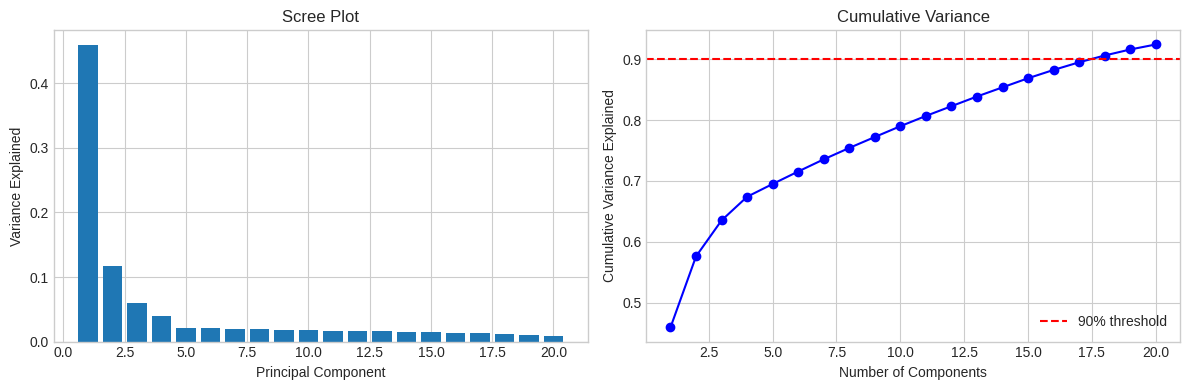

Components for 90% variance: 18


In [13]:
# PCA
pca = PCA(n_components=min(20, X_train_scaled.shape[1]))
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Variance explained
cumvar = np.cumsum(pca.explained_variance_ratio_)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot')

axes[1].plot(range(1, len(cumvar) + 1), cumvar, 'bo-')
axes[1].axhline(y=0.9, color='r', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

n_components_90 = np.argmax(cumvar >= 0.9) + 1
print(f"Components for 90% variance: {n_components_90}")

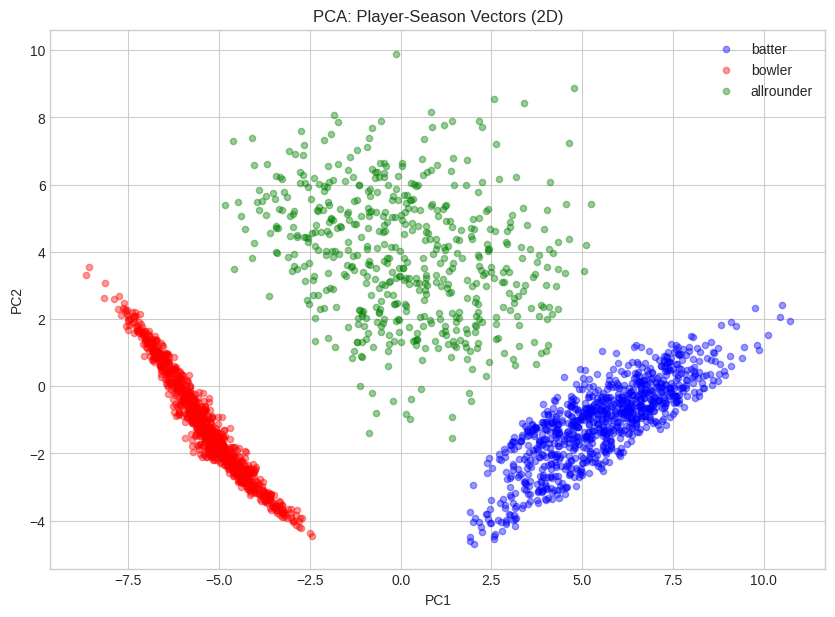

In [14]:
# 2D PCA visualization colored by player type
fig, ax = plt.subplots(figsize=(10, 7))
colors = {'batter': 'blue', 'bowler': 'red', 'allrounder': 'green'}
for ptype, color in colors.items():
    mask = features_train['player_type'] == ptype
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
              c=color, alpha=0.4, s=20, label=ptype)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA: Player-Season Vectors (2D)')
ax.legend()
plt.savefig(OUTPUT_DIR / 'pca_player_types.png', dpi=150, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


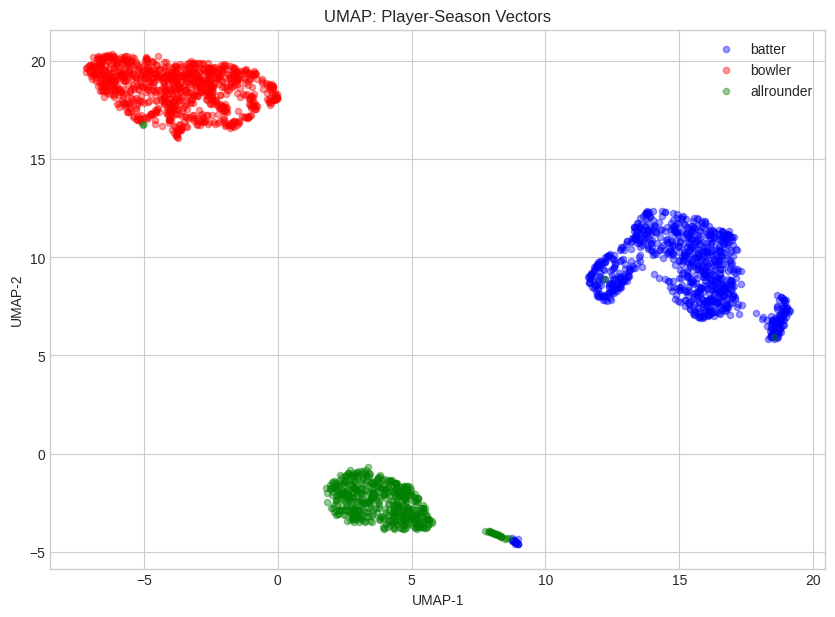

In [15]:
# UMAP visualization
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.3)
X_train_umap = reducer.fit_transform(X_train_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
for ptype, color in colors.items():
    mask = features_train['player_type'] == ptype
    ax.scatter(X_train_umap[mask, 0], X_train_umap[mask, 1],
              c=color, alpha=0.4, s=20, label=ptype)
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.set_title('UMAP: Player-Season Vectors')
ax.legend()
plt.show()

## Phase 4: Clustering

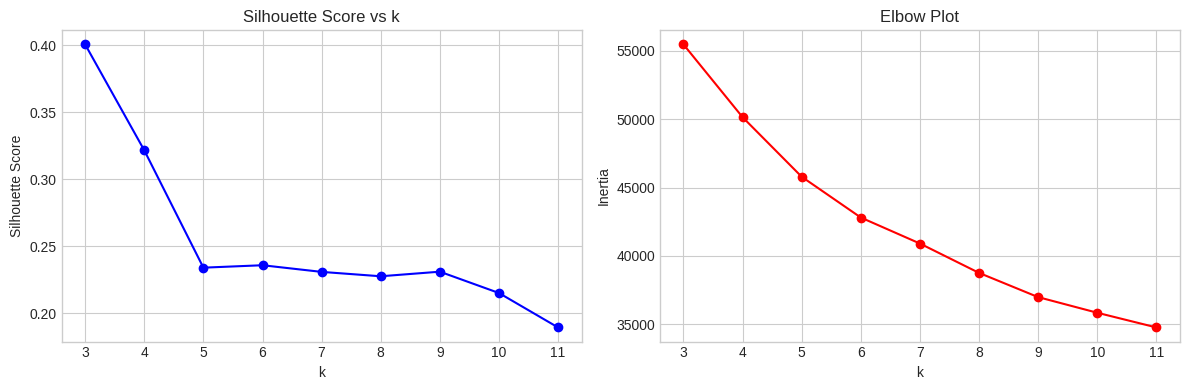

Best k by silhouette: 3 (score: 0.400)


In [16]:
# Determine optimal k using silhouette scores
# Use PCA-reduced features (90% variance) for clustering
X_cluster = X_train_pca[:, :n_components_90]

k_range = range(3, 12)
silhouette_scores = []
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    silhouette_scores.append(silhouette_score(X_cluster, labels))
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), silhouette_scores, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k')

axes[1].plot(list(k_range), inertias, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Inertia')
axes[1].set_title('Elbow Plot')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"Best k by silhouette: {best_k} (score: {max(silhouette_scores):.3f})")

In [17]:
# Fit final K-Means with best k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
features_train['cluster_kmeans'] = kmeans.fit_predict(X_cluster)

# Assign test data to clusters
X_test_cluster = X_test_pca[:, :n_components_90]
features_test['cluster_kmeans'] = kmeans.predict(X_test_cluster)

print("Train cluster distribution:")
print(features_train['cluster_kmeans'].value_counts().sort_index())

Train cluster distribution:
cluster_kmeans
0    522
1    982
2    954
Name: count, dtype: int64


In [18]:
# GMM for soft clustering
gmm = GaussianMixture(n_components=best_k, random_state=42, covariance_type='full')
gmm.fit(X_cluster)
features_train['cluster_gmm'] = gmm.predict(X_cluster)
gmm_probs_train = gmm.predict_proba(X_cluster)

features_test['cluster_gmm'] = gmm.predict(X_test_cluster)
gmm_probs_test = gmm.predict_proba(X_test_cluster)

print(f"GMM BIC: {gmm.bic(X_cluster):.0f}")
print(f"GMM AIC: {gmm.aic(X_cluster):.0f}")

GMM BIC: -12675
GMM AIC: -15980


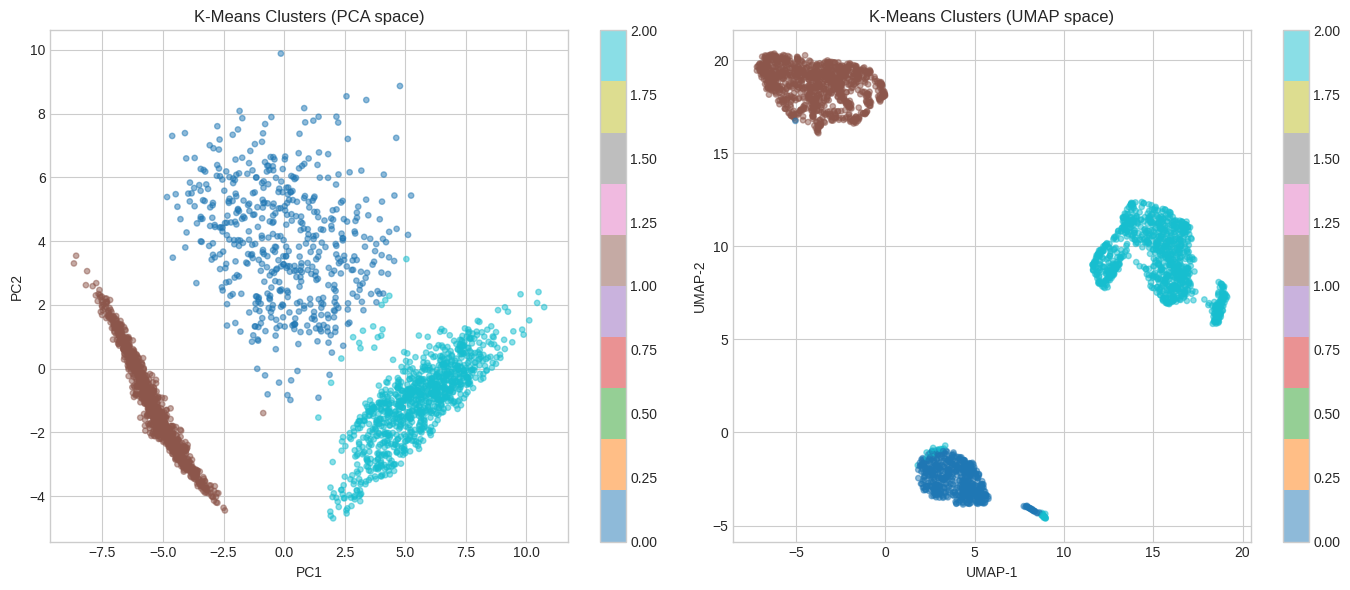

In [19]:
# Visualize clusters in 2D (PCA and UMAP space)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                           c=features_train['cluster_kmeans'], cmap='tab10', alpha=0.5, s=15)
axes[0].set_title('K-Means Clusters (PCA space)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(X_train_umap[:, 0], X_train_umap[:, 1],
                           c=features_train['cluster_kmeans'], cmap='tab10', alpha=0.5, s=15)
axes[1].set_title('K-Means Clusters (UMAP space)')
axes[1].set_xlabel('UMAP-1')
axes[1].set_ylabel('UMAP-2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'clusters_pca_umap.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Interpret clusters: look at mean feature values per cluster
cluster_profiles = features_train.groupby('cluster_kmeans')[feature_cols].mean()

# Show key distinguishing features per cluster
key_bat_features = ['bat_strike_rate', 'bat_boundary_pct', 'bat_dot_pct', 'bat_average',
                    'bat_phase_sr_powerplay', 'bat_phase_sr_death', 'acceleration',
                    'bat_avg_entry_delivery', 'bat_opener_pct']
key_bowl_features = ['bowl_economy', 'bowl_bowling_sr', 'bowl_dot_pct_bowl',
                     'bowl_phase_economy_powerplay', 'bowl_phase_economy_death']

key_features = [f for f in key_bat_features + key_bowl_features if f in feature_cols]
print("Cluster profiles (key features):")
cluster_profiles[key_features].round(2)

Cluster profiles (key features):


,bat_strike_rate,bat_boundary_pct,bat_dot_pct,bat_average,bat_phase_sr_powerplay,bat_phase_sr_death,bat_avg_entry_delivery,bat_opener_pct,bowl_economy,bowl_bowling_sr,bowl_dot_pct_bowl,bowl_phase_economy_powerplay,bowl_phase_economy_death
cluster_kmeans,,,,,,,,,,,,,
0,127.91,0.16,0.38,23.81,103.52,151.21,70.80,0.04,8.22,27.22,0.32,8.31,10.15
1,106.45,0.16,0.55,8.25,106.45,NaN,0.00,1.00,8.52,26.46,0.34,8.36,10.48
2,128.04,0.17,0.39,29.01,111.78,158.14,34.49,0.20,8.60,39.31,0.24,7.57,11.71


In [21]:
# Spot-check: look at well-known players in each cluster
known_players = ['V Kohli', 'MS Dhoni', 'AB de Villiers', 'JJ Bumrah',
                 'Rashid Khan', 'DJ Bravo', 'SP Narine', 'DA Warner',
                 'KL Rahul', 'RA Jadeja', 'CH Gayle', 'YS Chahal']

player_clusters = features_train[features_train['player'].isin(known_players)][['player', 'season', 'player_type', 'cluster_kmeans']]
player_clusters.sort_values(['player', 'season'])

,player,season,player_type,cluster_kmeans
85,AB de Villiers,2008,batter,2
86,AB de Villiers,2009,batter,2
87,AB de Villiers,2010,batter,2
88,AB de Villiers,2011,batter,2
89,AB de Villiers,2012,batter,2
...,...,...,...,...
2423,YS Chahal,2020,bowler,1
2424,YS Chahal,2021,bowler,1
2425,YS Chahal,2022,bowler,1
2426,YS Chahal,2023,bowler,1


## Phase 5: Team Composition Analysis

Compare archetype distributions of playoff vs non-playoff teams.

In [22]:
# We need to map players to teams per season
# Extract from the ball data: a player's team is who they bat/bowl for

def get_player_teams(data):
    """Get player-team-season mapping from ball data."""
    bat_teams = data[['striker', 'batting_team', 'season']].rename(
        columns={'striker': 'player', 'batting_team': 'team'})
    bowl_teams = data[['bowler', 'bowling_team', 'season']].rename(
        columns={'bowler': 'player', 'bowling_team': 'team'})
    all_teams = pd.concat([bat_teams, bowl_teams]).drop_duplicates()
    # Take most common team per player-season (handles edge cases)
    player_teams = all_teams.groupby(['player', 'season'])['team'].agg(
        lambda x: x.value_counts().index[0]
    ).reset_index()
    return player_teams

player_teams_train = get_player_teams(train_data)
player_teams_test = get_player_teams(test_data)

# Merge with features
features_train = features_train.merge(player_teams_train, on=['player', 'season'], how='left')
features_test = features_test.merge(player_teams_test, on=['player', 'season'], how='left')

print(f"Teams in training data: {features_train['team'].nunique()}")
features_train[['player', 'season', 'team', 'cluster_kmeans']].head(10)

Teams in training data: 19


,player,season,team,cluster_kmeans
0,A Ashish Reddy,2012,Deccan Chargers,1
1,A Ashish Reddy,2013,Sunrisers Hyderabad,0
2,A Ashish Reddy,2015,Sunrisers Hyderabad,0
3,A Badoni,2022,Lucknow Super Giants,2
4,A Badoni,2023,Lucknow Super Giants,2
5,A Badoni,2024,Lucknow Super Giants,2
6,A Chandila,2012,Rajasthan Royals,1
7,A Chandila,2013,Rajasthan Royals,1
8,A Chopra,2008,Kolkata Knight Riders,2
9,A Choudhary,2017,Royal Challengers Bangalore,1


In [23]:
# IPL Playoff teams by season (top 4)
playoff_teams = {
    2008: ['Rajasthan Royals', 'Chennai Super Kings', 'Delhi Daredevils', 'Kings XI Punjab'],
    2009: ['Deccan Chargers', 'Royal Challengers Bangalore', 'Delhi Daredevils', 'Chennai Super Kings'],
    2010: ['Chennai Super Kings', 'Mumbai Indians', 'Royal Challengers Bangalore', 'Deccan Chargers'],
    2011: ['Chennai Super Kings', 'Royal Challengers Bangalore', 'Mumbai Indians', 'Kolkata Knight Riders'],
    2012: ['Kolkata Knight Riders', 'Chennai Super Kings', 'Delhi Daredevils', 'Mumbai Indians'],
    2013: ['Mumbai Indians', 'Chennai Super Kings', 'Rajasthan Royals', 'Sunrisers Hyderabad'],
    2014: ['Kolkata Knight Riders', 'Kings XI Punjab', 'Chennai Super Kings', 'Mumbai Indians'],
    2015: ['Mumbai Indians', 'Chennai Super Kings', 'Royal Challengers Bangalore', 'Rajasthan Royals'],
    2016: ['Sunrisers Hyderabad', 'Royal Challengers Bangalore', 'Gujarat Lions', 'Kolkata Knight Riders'],
    2017: ['Mumbai Indians', 'Rising Pune Supergiant', 'Sunrisers Hyderabad', 'Kolkata Knight Riders'],
    2018: ['Chennai Super Kings', 'Sunrisers Hyderabad', 'Kolkata Knight Riders', 'Rajasthan Royals'],
    2019: ['Mumbai Indians', 'Chennai Super Kings', 'Delhi Capitals', 'Sunrisers Hyderabad'],
    2020: ['Mumbai Indians', 'Delhi Capitals', 'Sunrisers Hyderabad', 'Royal Challengers Bangalore'],
    2021: ['Chennai Super Kings', 'Kolkata Knight Riders', 'Delhi Capitals', 'Royal Challengers Bangalore'],
    2022: ['Gujarat Titans', 'Rajasthan Royals', 'Lucknow Super Giants', 'Royal Challengers Bangalore'],
    2023: ['Chennai Super Kings', 'Gujarat Titans', 'Mumbai Indians', 'Lucknow Super Giants'],
    2024: ['Kolkata Knight Riders', 'Sunrisers Hyderabad', 'Rajasthan Royals', 'Royal Challengers Bengaluru'],
}

# Label each team-season as playoff or not
def is_playoff(row):
    season = row['season']
    team = row['team']
    if season in playoff_teams:
        return team in playoff_teams[season]
    return None

features_train['is_playoff'] = features_train.apply(is_playoff, axis=1)
print(features_train['is_playoff'].value_counts(dropna=False))

is_playoff
False    1350
True     1108
Name: count, dtype: int64


In [24]:
# Compute archetype distribution per team-season
team_compositions = features_train.groupby(['team', 'season', 'is_playoff'])['cluster_kmeans'].value_counts(
    normalize=True
).unstack(fill_value=0).reset_index()

team_compositions.columns.name = None
cluster_cols = [c for c in team_compositions.columns if isinstance(c, (int, np.integer))]

print(f"Team-season compositions: {len(team_compositions)}")
team_compositions.head()

Team-season compositions: 146


,team,season,is_playoff,0,1,2
0,Chennai Super Kings,2008,True,0.062500,0.437500,0.500000
1,Chennai Super Kings,2009,True,0.235294,0.411765,0.352941
2,Chennai Super Kings,2010,True,0.166667,0.500000,0.333333
3,Chennai Super Kings,2011,True,0.142857,0.428571,0.428571
4,Chennai Super Kings,2012,True,0.266667,0.400000,0.333333


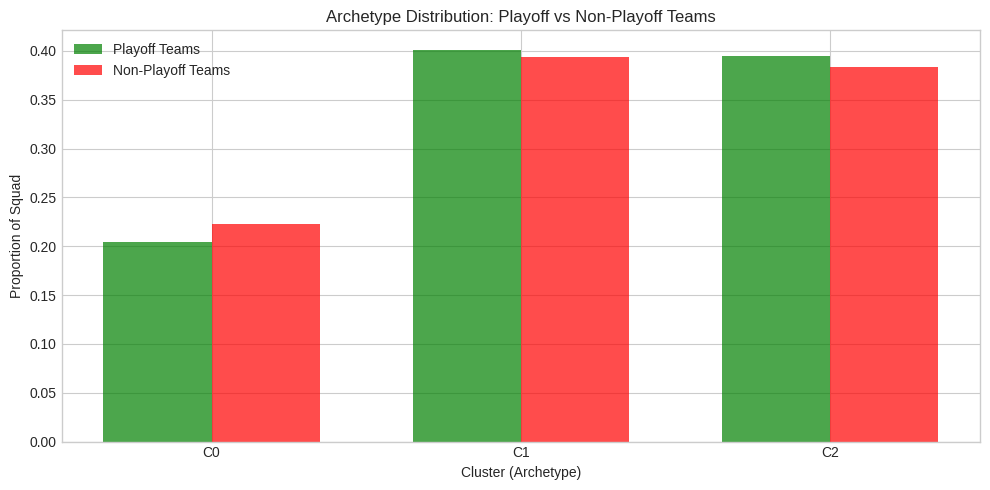

In [25]:
# Compare playoff vs non-playoff archetype distributions
playoff_comp = team_compositions[team_compositions['is_playoff'] == True][cluster_cols].mean()
non_playoff_comp = team_compositions[team_compositions['is_playoff'] == False][cluster_cols].mean()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cluster_cols))
width = 0.35

ax.bar(x - width/2, playoff_comp.values, width, label='Playoff Teams', color='green', alpha=0.7)
ax.bar(x + width/2, non_playoff_comp.values, width, label='Non-Playoff Teams', color='red', alpha=0.7)
ax.set_xlabel('Cluster (Archetype)')
ax.set_ylabel('Proportion of Squad')
ax.set_title('Archetype Distribution: Playoff vs Non-Playoff Teams')
ax.set_xticks(x)
ax.set_xticklabels([f'C{c}' for c in cluster_cols])
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'playoff_vs_nonplayoff.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Statistical test: are the distributions significantly different?
print("Per-archetype comparison (playoff vs non-playoff):")
print(f"{'Cluster':<10} {'Playoff Mean':<15} {'Non-PO Mean':<15} {'t-stat':<10} {'p-value':<10}")
print("-" * 60)

for c in cluster_cols:
    po_vals = team_compositions[team_compositions['is_playoff'] == True][c]
    npo_vals = team_compositions[team_compositions['is_playoff'] == False][c]
    t_stat, p_val = stats.ttest_ind(po_vals, npo_vals)
    sig = '*' if p_val < 0.05 else ''
    print(f"C{c:<9} {po_vals.mean():<15.3f} {npo_vals.mean():<15.3f} {t_stat:<10.3f} {p_val:<10.4f} {sig}")

Per-archetype comparison (playoff vs non-playoff):
Cluster    Playoff Mean    Non-PO Mean     t-stat     p-value   
------------------------------------------------------------
C0         0.204           0.223           -1.349     0.1795     
C1         0.401           0.393           0.541      0.5894     
C2         0.395           0.384           1.068      0.2871     


## Phase 6: Replacement Recommender

In [27]:
def find_replacement(player_name, season, features_df, pca_features, top_n=5, exclude_team=None):
    """
    Find the most similar players to a given player based on their feature vector.
    Uses the most recent season's data for the target player.
    """
    # Get target player's vector
    target_mask = (features_df['player'] == player_name) & (features_df['season'] == season)
    if target_mask.sum() == 0:
        # Try most recent season
        player_data = features_df[features_df['player'] == player_name]
        if len(player_data) == 0:
            print(f"Player '{player_name}' not found.")
            return None
        season = player_data['season'].max()
        target_mask = (features_df['player'] == player_name) & (features_df['season'] == season)

    target_idx = features_df[target_mask].index[0]
    target_vec = pca_features[features_df.index.get_loc(target_idx)]

    # Compute distances to all other players (use their most recent season)
    latest_season_per_player = features_df.groupby('player')['season'].max().reset_index()
    latest_season_per_player.columns = ['player', 'latest_season']

    candidates = features_df.merge(latest_season_per_player, on='player')
    candidates = candidates[candidates['season'] == candidates['latest_season']]
    candidates = candidates[candidates['player'] != player_name]

    if exclude_team:
        candidates = candidates[candidates['team'] != exclude_team]

    candidate_indices = [features_df.index.get_loc(idx) for idx in candidates.index]
    candidate_vecs = pca_features[candidate_indices]

    distances = np.linalg.norm(candidate_vecs - target_vec, axis=1)
    candidates = candidates.copy()
    candidates['distance'] = distances

    result = candidates.nsmallest(top_n, 'distance')[['player', 'season', 'team', 'cluster_kmeans', 'player_type', 'distance']]
    print(f"\nTop {top_n} replacements for {player_name} (season {season}):")
    return result

# Example: find replacements for a departing player
find_replacement('MS Dhoni', 2024, features_train, X_cluster)


Top 5 replacements for MS Dhoni (season 2024):


,player,season,team,cluster_kmeans,player_type,distance
1841,Ramandeep Singh,2024,Kolkata Knight Riders,2,batter,1.839714
1283,MK Lomror,2024,Royal Challengers Bengaluru,2,batter,1.902454
275,Ashutosh Sharma,2024,Punjab Kings,2,batter,2.065933
235,Abdul Samad,2024,Sunrisers Hyderabad,2,batter,2.366685
2046,SO Hetmyer,2024,Rajasthan Royals,2,batter,2.605889


In [28]:
find_replacement('JJ Bumrah', 2024, features_train, X_cluster)


Top 5 replacements for JJ Bumrah (season 2024):


,player,season,team,cluster_kmeans,player_type,distance
2209,T Natarajan,2024,Sunrisers Hyderabad,1,bowler,1.570748
2197,Sohail Tanvir,2008,Rajasthan Royals,1,bowler,1.772222
2260,TU Deshpande,2024,Chennai Super Kings,1,bowler,2.054716
712,HV Patel,2024,Punjab Kings,1,bowler,2.142321
282,Avesh Khan,2024,Rajasthan Royals,1,bowler,2.307933


## Phase 7: Validation on Test Set (2025-2026)

In [29]:
# Check if clusters are stable: do players keep similar cluster assignments across seasons?
# For players appearing in both train and test

train_latest = features_train.groupby('player').apply(
    lambda x: x.loc[x['season'].idxmax()]
).reset_index(drop=True)[['player', 'cluster_kmeans']].rename(columns={'cluster_kmeans': 'cluster_train'})

test_clusters = features_test[['player', 'season', 'cluster_kmeans']].rename(columns={'cluster_kmeans': 'cluster_test'})

overlap = test_clusters.merge(train_latest, on='player')
overlap['same_cluster'] = overlap['cluster_train'] == overlap['cluster_test']

stability = overlap['same_cluster'].mean()
print(f"Players in both train & test: {len(overlap)}")
print(f"Cluster stability (same cluster): {stability:.1%}")
print(f"\nCluster transition matrix:")
pd.crosstab(overlap['cluster_train'], overlap['cluster_test'], margins=True)

Players in both train & test: 270
Cluster stability (same cluster): 86.7%

Cluster transition matrix:


/tmp/ipykernel_26706/3054878243.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_latest = features_train.groupby('player').apply(


cluster_test,0,1,2,All
cluster_train,,,,
0,26,15,2,43
1,14,94,0,108
2,5,0,114,119
All,45,109,116,270


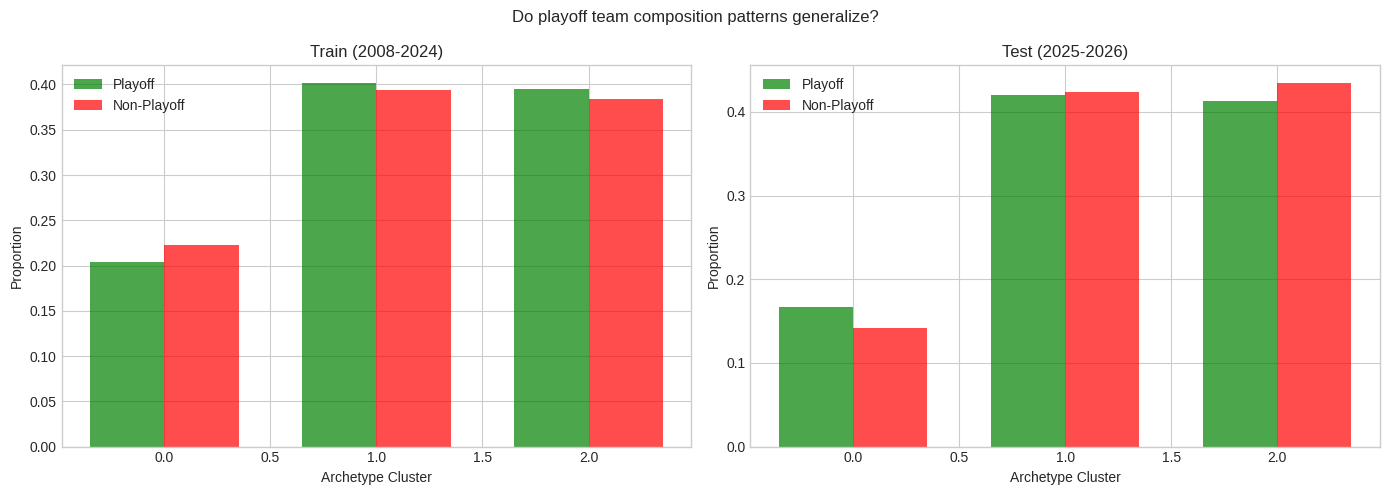

In [30]:
# Validate team composition patterns on test seasons
# Do playoff teams in 2025/2026 follow the same archetype patterns?

# Playoff teams for test seasons (derived from match data - playoff matches at end of season)
# 2025: Final RCB vs PBKS (Jun 3), playoffs involved MI, GT, PBKS, RCB
# 2026: Final GT vs RCB (May 31), playoffs involved GT, RCB, RR, SRH
playoff_teams_test = {
    2025: ['Mumbai Indians', 'Gujarat Titans', 'Punjab Kings', 'Royal Challengers Bengaluru'],
    2026: ['Gujarat Titans', 'Royal Challengers Bengaluru', 'Rajasthan Royals', 'Sunrisers Hyderabad'],
}

features_test['is_playoff'] = features_test.apply(
    lambda r: r['team'] in playoff_teams_test.get(r['season'], []), axis=1)

test_compositions = features_test.groupby(['team', 'season', 'is_playoff'])['cluster_kmeans'].value_counts(
    normalize=True).unstack(fill_value=0).reset_index()
test_compositions.columns.name = None

# Compare test playoff vs non-playoff (same analysis as training)
test_cluster_cols = [c for c in test_compositions.columns if isinstance(c, (int, np.integer))]
test_po = test_compositions[test_compositions['is_playoff'] == True][test_cluster_cols].mean()
test_npo = test_compositions[test_compositions['is_playoff'] == False][test_cluster_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training pattern
axes[0].bar(np.arange(len(cluster_cols)) - 0.175, playoff_comp.values, 0.35, label='Playoff', color='green', alpha=0.7)
axes[0].bar(np.arange(len(cluster_cols)) + 0.175, non_playoff_comp.values, 0.35, label='Non-Playoff', color='red', alpha=0.7)
axes[0].set_title('Train (2008-2024)')
axes[0].set_xlabel('Archetype Cluster')
axes[0].set_ylabel('Proportion')
axes[0].legend()

# Test pattern
axes[1].bar(np.arange(len(test_cluster_cols)) - 0.175, test_po.values, 0.35, label='Playoff', color='green', alpha=0.7)
axes[1].bar(np.arange(len(test_cluster_cols)) + 0.175, test_npo.values, 0.35, label='Non-Playoff', color='red', alpha=0.7)
axes[1].set_title('Test (2025-2026)')
axes[1].set_xlabel('Archetype Cluster')
axes[1].set_ylabel('Proportion')
axes[1].legend()

plt.suptitle('Do playoff team composition patterns generalize?')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'train_vs_test_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Replacement recommender validation:
# For players who changed teams between 2024 and 2025, check if the acquiring team
# got a player from a similar cluster to someone they lost

players_2024 = features_train[features_train['season'] == 2024][['player', 'team', 'cluster_kmeans']]
players_2025 = features_test[features_test['season'] == 2025][['player', 'team', 'cluster_kmeans']]

# Players who moved teams
moved = players_2024.merge(players_2025, on='player', suffixes=('_2024', '_2025'))
moved = moved[moved['team_2024'] != moved['team_2025']]
print(f"Players who changed teams: {len(moved)}")
if len(moved) > 0:
    print(moved[['player', 'team_2024', 'team_2025', 'cluster_kmeans_2024', 'cluster_kmeans_2025']].head(15))

Players who changed teams: 70
                player             team_2024                    team_2025  \
1             A Kamboj        Mumbai Indians          Chennai Super Kings   
2             A Nortje        Delhi Capitals        Kolkata Knight Riders   
5           AK Markram   Sunrisers Hyderabad         Lucknow Super Giants   
6            AM Rahane   Chennai Super Kings        Kolkata Knight Riders   
8          Abdul Samad   Sunrisers Hyderabad         Lucknow Super Giants   
11       Akash Madhwal        Mumbai Indians             Rajasthan Royals   
12         Arshad Khan  Lucknow Super Giants               Gujarat Titans   
14     Ashutosh Sharma          Punjab Kings               Delhi Capitals   
15          Avesh Khan      Rajasthan Royals         Lucknow Super Giants   
16  Azmatullah Omarzai        Gujarat Titans                 Punjab Kings   
17             B Kumar   Sunrisers Hyderabad  Royal Challengers Bengaluru   
20            D Brevis        Mumbai Indians  

# Save all computed data to Drive
features_train.to_csv(OUTPUT_DIR / 'features_train.csv', index=False)
features_test.to_csv(OUTPUT_DIR / 'features_test.csv', index=False)
team_compositions.to_csv(OUTPUT_DIR / 'team_compositions_train.csv', index=False)
test_compositions.to_csv(OUTPUT_DIR / 'team_compositions_test.csv', index=False)

# Save cluster profiles
cluster_profiles = features_train.groupby('cluster_kmeans')[feature_cols].mean()
cluster_profiles.to_csv(OUTPUT_DIR / 'cluster_profiles.csv')

print(f"All outputs saved to: {OUTPUT_DIR}")
print(f"\nFigures saved:")
for f in sorted(OUTPUT_DIR.glob('*.png')):
    print(f"  {f.name}")
print(f"\nData saved:")
for f in sorted(OUTPUT_DIR.glob('*.csv')):
    print(f"  {f.name}")

In [32]:
def search_player(query):
    """Search for players by partial name (case-insensitive).
    Example: search_player('bumrah') -> ['JJ Bumrah']
    """
    all_players = sorted(features_train['player'].unique())
    matches = [p for p in all_players if query.lower() in p.lower()]
    if not matches:
        print(f"No players found matching '{query}'")
    else:
        print(f"Found {len(matches)} match(es) for '{query}':")
        for p in matches:
            seasons = sorted(features_train[features_train['player'] == p]['season'].unique())
            print(f"  {p}  (seasons: {seasons[0]}-{seasons[-1]})")
    return matches

# Examples:
search_player('bumrah')
search_player('kohli')
search_player('dhoni')

Found 1 match(es) for 'bumrah':
  JJ Bumrah  (seasons: 2013-2024)
Found 1 match(es) for 'kohli':
  V Kohli  (seasons: 2008-2024)
Found 1 match(es) for 'dhoni':
  MS Dhoni  (seasons: 2008-2024)


['MS Dhoni']

In [33]:
search_player("warner")

Found 1 match(es) for 'warner':
  DA Warner  (seasons: 2009-2024)


['DA Warner']

In [34]:
find_replacement('DA Warner', 2016, features_train, X_cluster, top_n = 20)


Top 20 replacements for DA Warner (season 2016):


,player,season,team,cluster_kmeans,player_type,distance
2303,V Kohli,2024,Royal Challengers Bengaluru,2,batter,1.540700
553,DP Conway,2023,Chennai Super Kings,2,batter,3.548427
1742,RD Gaikwad,2024,Chennai Super Kings,2,batter,4.261777
1024,KL Rahul,2024,Lucknow Super Giants,2,batter,4.871589
2404,YBK Jaiswal,2024,Rajasthan Royals,2,batter,5.002121
2252,TM Head,2024,Sunrisers Hyderabad,2,batter,5.048611
1765,RG Sharma,2024,Mumbai Indians,2,batter,5.052318
316,B Sai Sudharsan,2024,Gujarat Titans,2,batter,5.303306
1548,PD Salt,2024,Kolkata Knight Riders,2,batter,5.353635
1668,R Parag,2024,Rajasthan Royals,2,batter,5.492393


## Summary & Next Steps

Key outputs:
1. **Player archetypes** discovered via unsupervised clustering on engineered features
2. **Team composition patterns** comparing playoff vs non-playoff squads
3. **Replacement recommender** using feature-space distance
4. **Validation** on held-out 2025/2026 seasons

Potential extensions:
- HDBSCAN for density-based clustering (handles outliers better)
- Temporal analysis: how do player archetypes evolve over careers?
- Auction price analysis: are certain archetypes overvalued?
- Match outcome prediction from team archetype composition